**Rough Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from utils import non_uniform_grid, set_matplotlib_style
from rough_bergomi import RoughBergomiModel
from data import get_xi0_interpolator, get_params, DATES

set_matplotlib_style()
SEED = 1234
SAVEFIG = False

# SSR Expansions

## Figure 1

In [20]:
# Parameters from Bayer, Friz, Gatheral (2016) - Section 5.2.1
id = 2  # id = 1 or 2
params = {"eta": 1.9, "rho": -0.9}
if id == 1:
    params["H"] = 0.3
elif id == 2:
    params["H"] = 0.07
else:
    raise ValueError("id must be 1 or 2")
xi0 = lambda t: 0.2**2 * np.ones_like(t)
rbergomi = RoughBergomiModel(params=params, xi0=xi0)

In [21]:
rbergomi

RoughBergomiModel with parameters:
eta=1.9, rho=-0.9, H=0.07, s0=1.0

In [22]:
# n_mc = 1 * 10**5
# n_disc = 100
n_mc = 3 * 10**5
n_disc = 300
eps_ssr = 1e-3
n_quad = 40

In [24]:
# compute true beta, atm skew and SSRs
Ts = non_uniform_grid(7 / 365, 3, 15, 1.5)
out = rbergomi.ssr_all(
    Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    eps_ssr=eps_ssr,
    seed=SEED,
    n_quad=n_quad,
    conditioning=True,
    n_loop=12,
    n_batch=10,
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [0.01917808 0.07048774 0.16430372 0.2857909  0.42965537 0.59283753
 0.77327301 0.9694463  1.18018317 1.40453892 1.64173202 1.8911019
 2.15208062 2.42417304 2.70694247 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 12
Number of independent batches: 10


Running batch 1/10 with seed 4206279609
1/16: expiry 0.0192
2/16: expiry 0.0705
3/16: expiry 0.1643
4/16: expiry 0.2858
5/16: expiry 0.4297
6/16: expiry 0.5928
7/16: expiry 0.7733
8/16: expiry 0.9694
9/16: expiry 1.1802
10/16: expiry 1.4045
11/16: expiry 1.6417
12/16: expiry 1.8911
13/16: expiry 2.1521
14/16: expiry 2.4242
15/16: expiry 2.7069
16/16: expiry 3.0000

Running batch 2/10 with seed 4194893554
1/16: expiry 0.0192
2/16: expiry 0.0705
3/16: expiry 0.1643
4/16: expiry 0.2858
5/16: expiry 0.4297
6/16: expiry 0.5928
7/16: expiry 0.7733
8/16: expiry 0.9694
9/16:

In [25]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 3, 200)
out_bg = rbergomi.ssr_bg_all(Ts_bg, n_quad=n_quad)

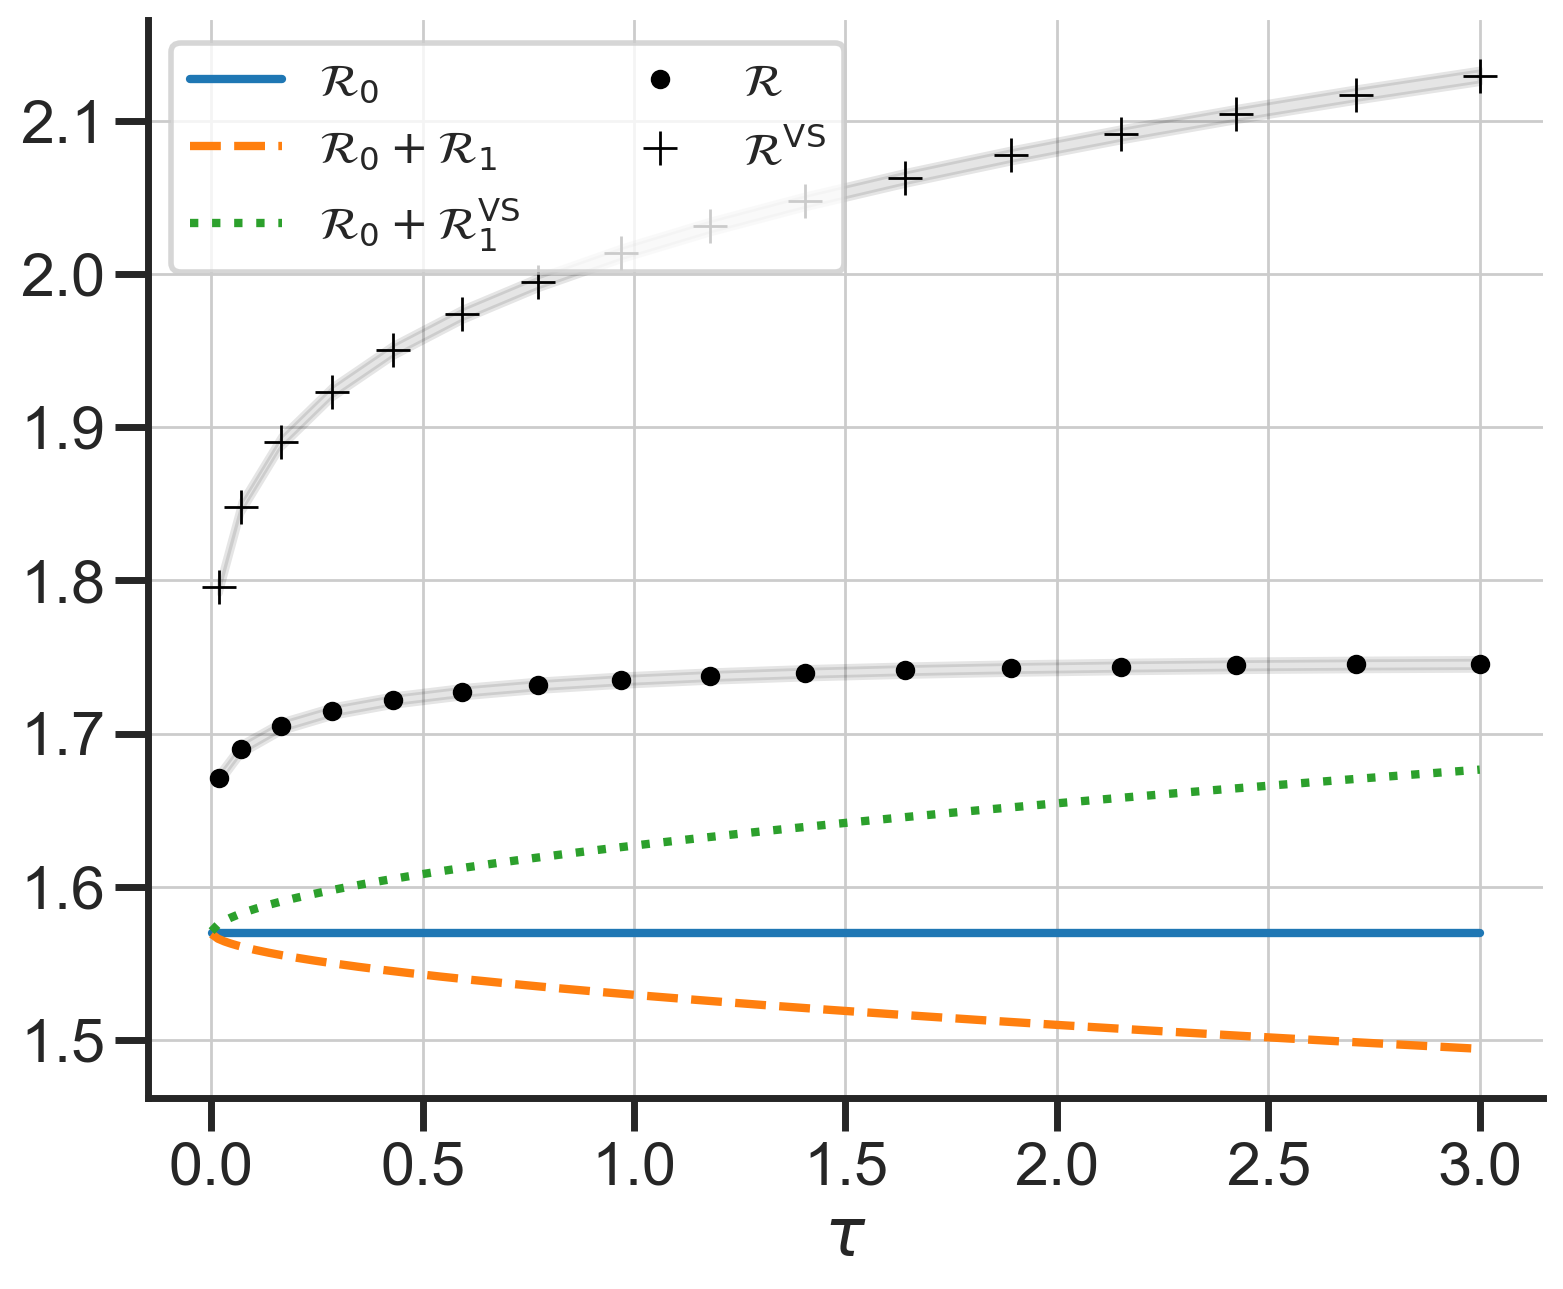

In [26]:
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_fd"], ".k", label=r"$\mathcal{R}$")
ax.fill_between(Ts, out["ssr_fd_low"], out["ssr_fd_high"], color="k", alpha=0.1)
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.fill_between(Ts, out["ssr_vs_low"], out["ssr_vs_high"], color="k", alpha=0.1)
# ax.plot([0], [rbergomi.H + 3 / 2], "k*")
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rbergomi/rbergomi_set_{id}_ssr.pdf", bbox_inches="tight")
plt.show()

### Hybrid

In [27]:
# using same maturities for SSRs
out_bg = rbergomi.ssr_bg_all(Ts, n_quad)

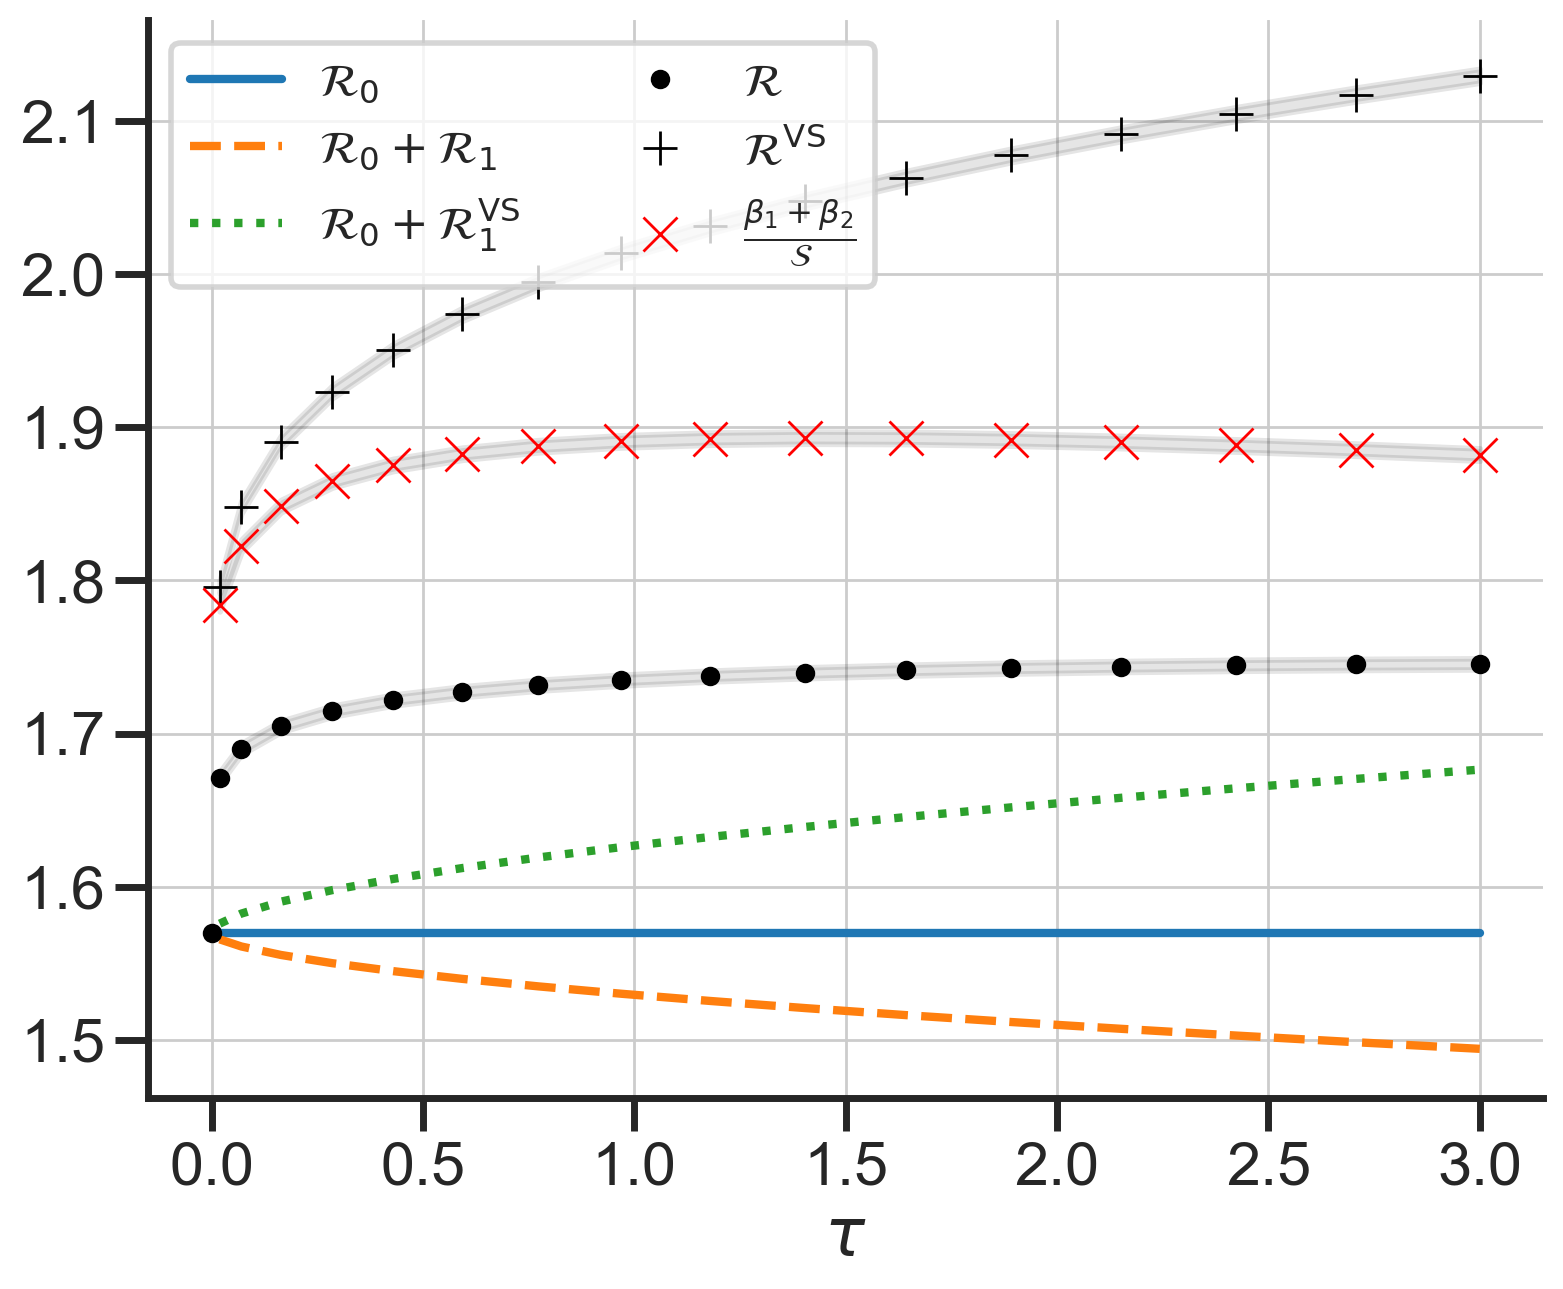

In [28]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_fd"], ".k", label=r"$\mathcal{R}$")
ax.fill_between(Ts, out["ssr_fd_low"], out["ssr_fd_high"], color="k", alpha=0.1)
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.fill_between(Ts, out["ssr_vs_low"], out["ssr_vs_high"], color="k", alpha=0.1)
# hybrid formula
ax.plot(
    Ts,
    (out_bg["beta_1"] + out_bg["beta_2"]) / out["atm_skew"],
    "rx",
    label=r"$\frac{\beta_1+\beta_2}{\mathcal{S}}$",
)
ax.fill_between(
    Ts,
    (out_bg["beta_1"] + out_bg["beta_2"]) / out["atm_skew_high"],
    (out_bg["beta_1"] + out_bg["beta_2"]) / out["atm_skew_low"],
    color="k",
    alpha=0.1,
)
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
ax.plot([0], [rbergomi.H + 3 / 2], ".k")
if SAVEFIG:
    fig.savefig(
        f"figures/rbergomi/rbergomi_set_{id}_ssr_hybrid.pdf", bbox_inches="tight"
    )
plt.show()

## Market data (Figure 7)

In [11]:
# parameters
date = DATES[0]
print(f"Using parameters from {date}")

model = "rough_bergomi"
kind_interp = "cubic"
xi0 = get_xi0_interpolator(date, model, kind=kind_interp)
params = get_params(date=date, model=model)

# model
rbergomi = RoughBergomiModel(params=params, xi0=xi0)
rbergomi

Using parameters from 2024-05-06


RoughBergomiModel with parameters:
H=0.23, eta=1.5, rho=-0.62, s0=1.0

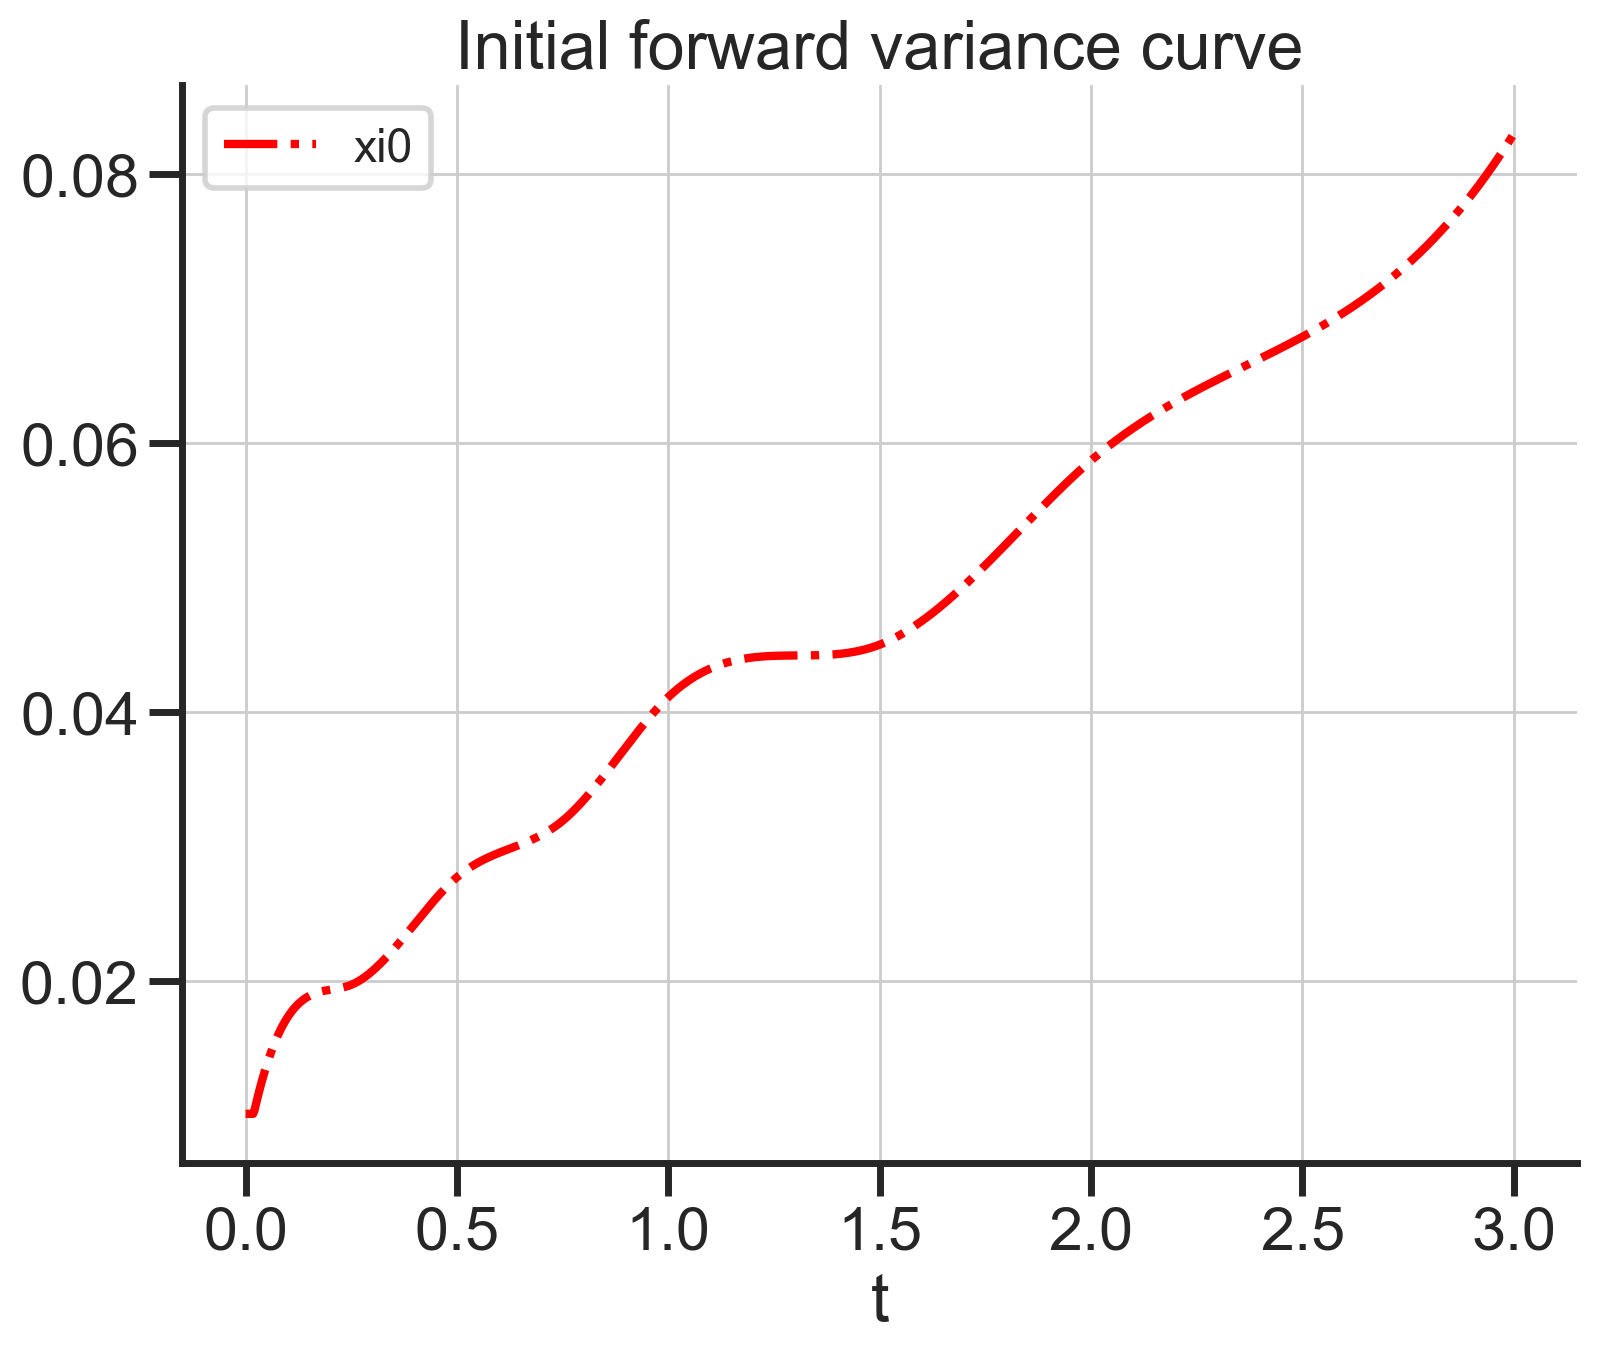

In [12]:
# plot xi0
us = np.linspace(0.0, 3.0, 1000)
fig, ax = plt.subplots()
ax.plot(us, xi0(us), "r-.", label="xi0")
ax.set_xlabel("t")
ax.set_title("Initial forward variance curve")
ax.legend()
plt.show()

In [13]:
# compute true beta, atm skew and SSRs
Ts = non_uniform_grid(7 / 365, 3, 15, 1.5)
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-3

out = rbergomi.ssr_all(
    Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=12,
    n_batch=10,
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [0.01917808 0.07048774 0.16430372 0.2857909  0.42965537 0.59283753
 0.77327301 0.9694463  1.18018317 1.40453892 1.64173202 1.8911019
 2.15208062 2.42417304 2.70694247 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 12
Number of independent batches: 10


Running batch 1/10 with seed 4206279609
1/16: expiry 0.0192
2/16: expiry 0.0705
3/16: expiry 0.1643
4/16: expiry 0.2858
5/16: expiry 0.4297
6/16: expiry 0.5928
7/16: expiry 0.7733
8/16: expiry 0.9694
9/16: expiry 1.1802
10/16: expiry 1.4045
11/16: expiry 1.6417
12/16: expiry 1.8911
13/16: expiry 2.1521
14/16: expiry 2.4242
15/16: expiry 2.7069
16/16: expiry 3.0000

Running batch 2/10 with seed 4194893554
1/16: expiry 0.0192
2/16: expiry 0.0705
3/16: expiry 0.1643
4/16: expiry 0.2858
5/16: expiry 0.4297
6/16: expiry 0.5928
7/16: expiry 0.7733
8/16: expiry 0.9694
9/16:

In [14]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 3, 200)
out_bg = rbergomi.ssr_bg_all(Ts_bg, n_quad=n_quad)

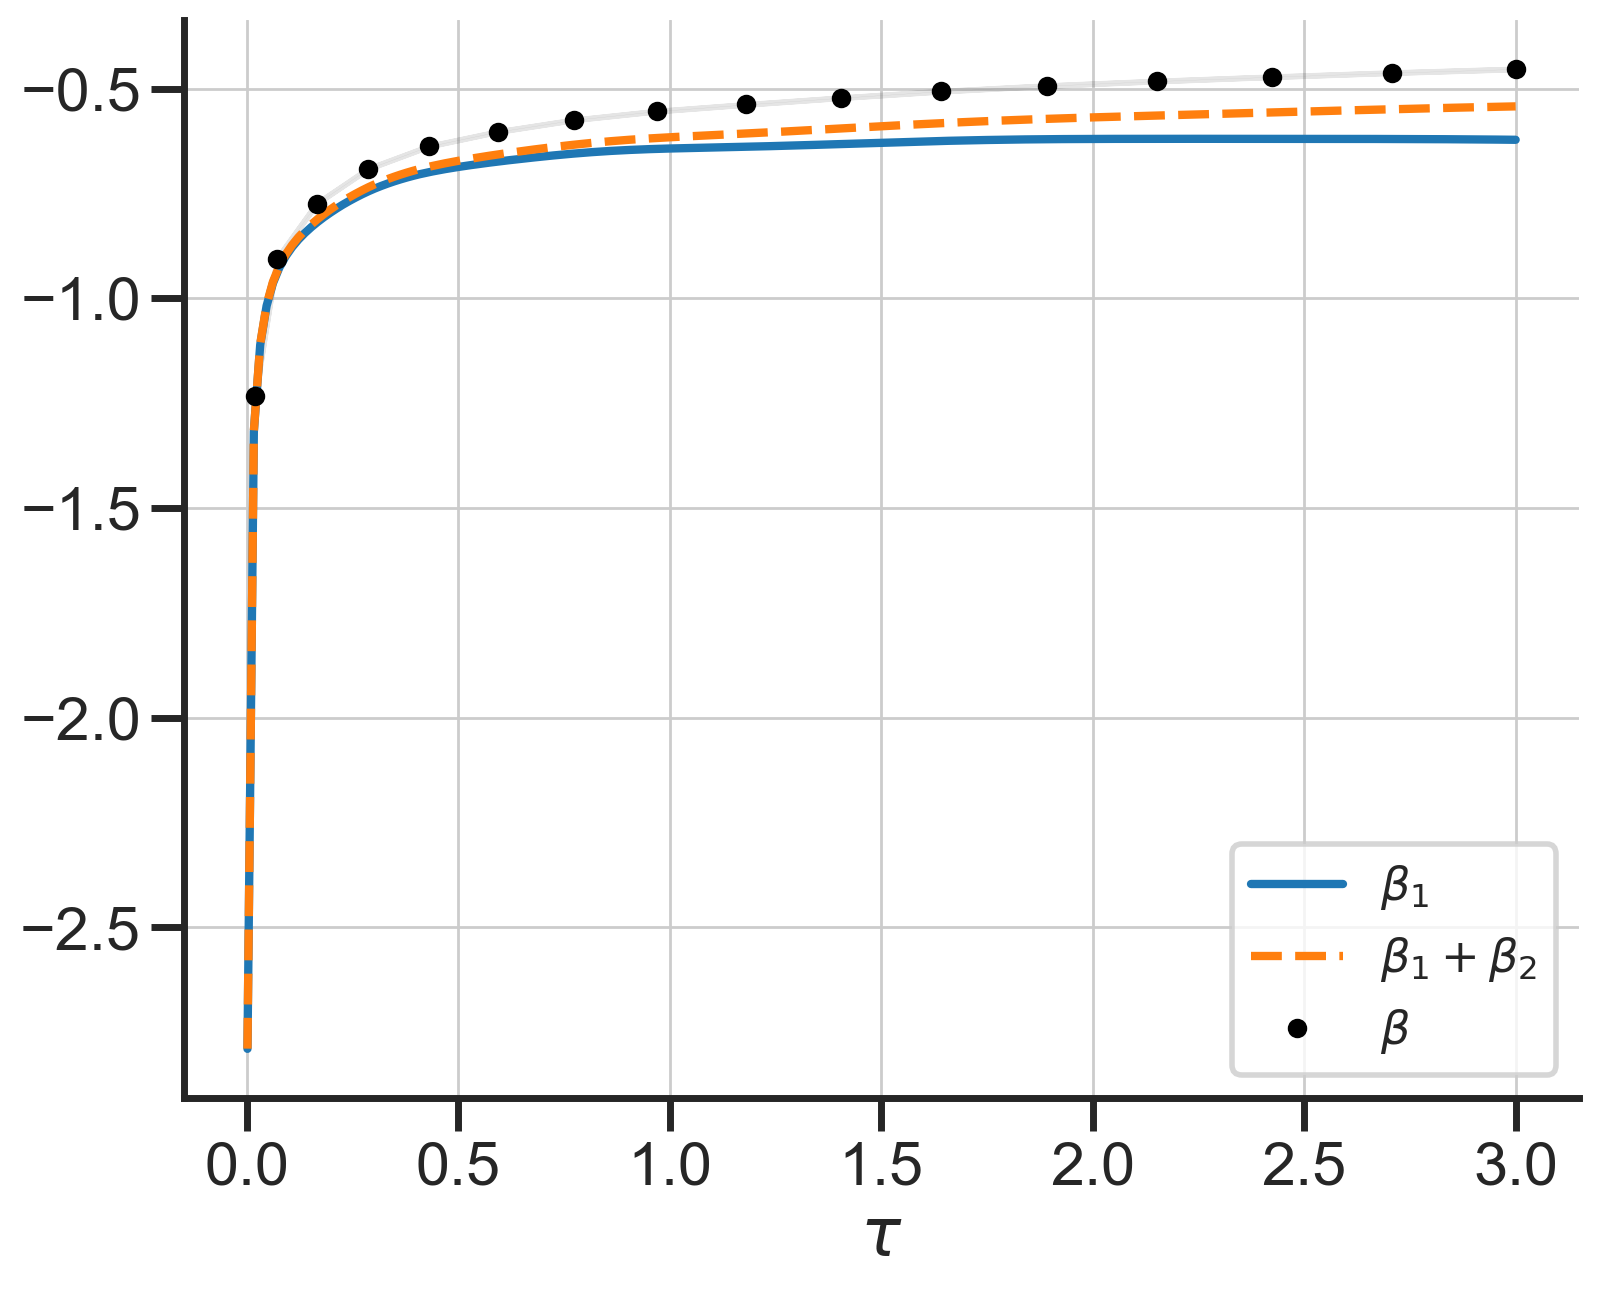

In [15]:
# plot beta
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["beta_1"], "-", label=r"$\beta_1$")
ax.plot(Ts_bg, out_bg["beta_1"] + out_bg["beta_2"], "--", label=r"$\beta_1+\beta_2$")
ax.plot(Ts, out["beta"], ".k", label=r"$\beta$")
ax.fill_between(Ts, out["beta_low"], out["beta_high"], color="k", alpha=0.1)
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rbergomi/rbergomi_{date}_beta.pdf", bbox_inches="tight")
plt.show()

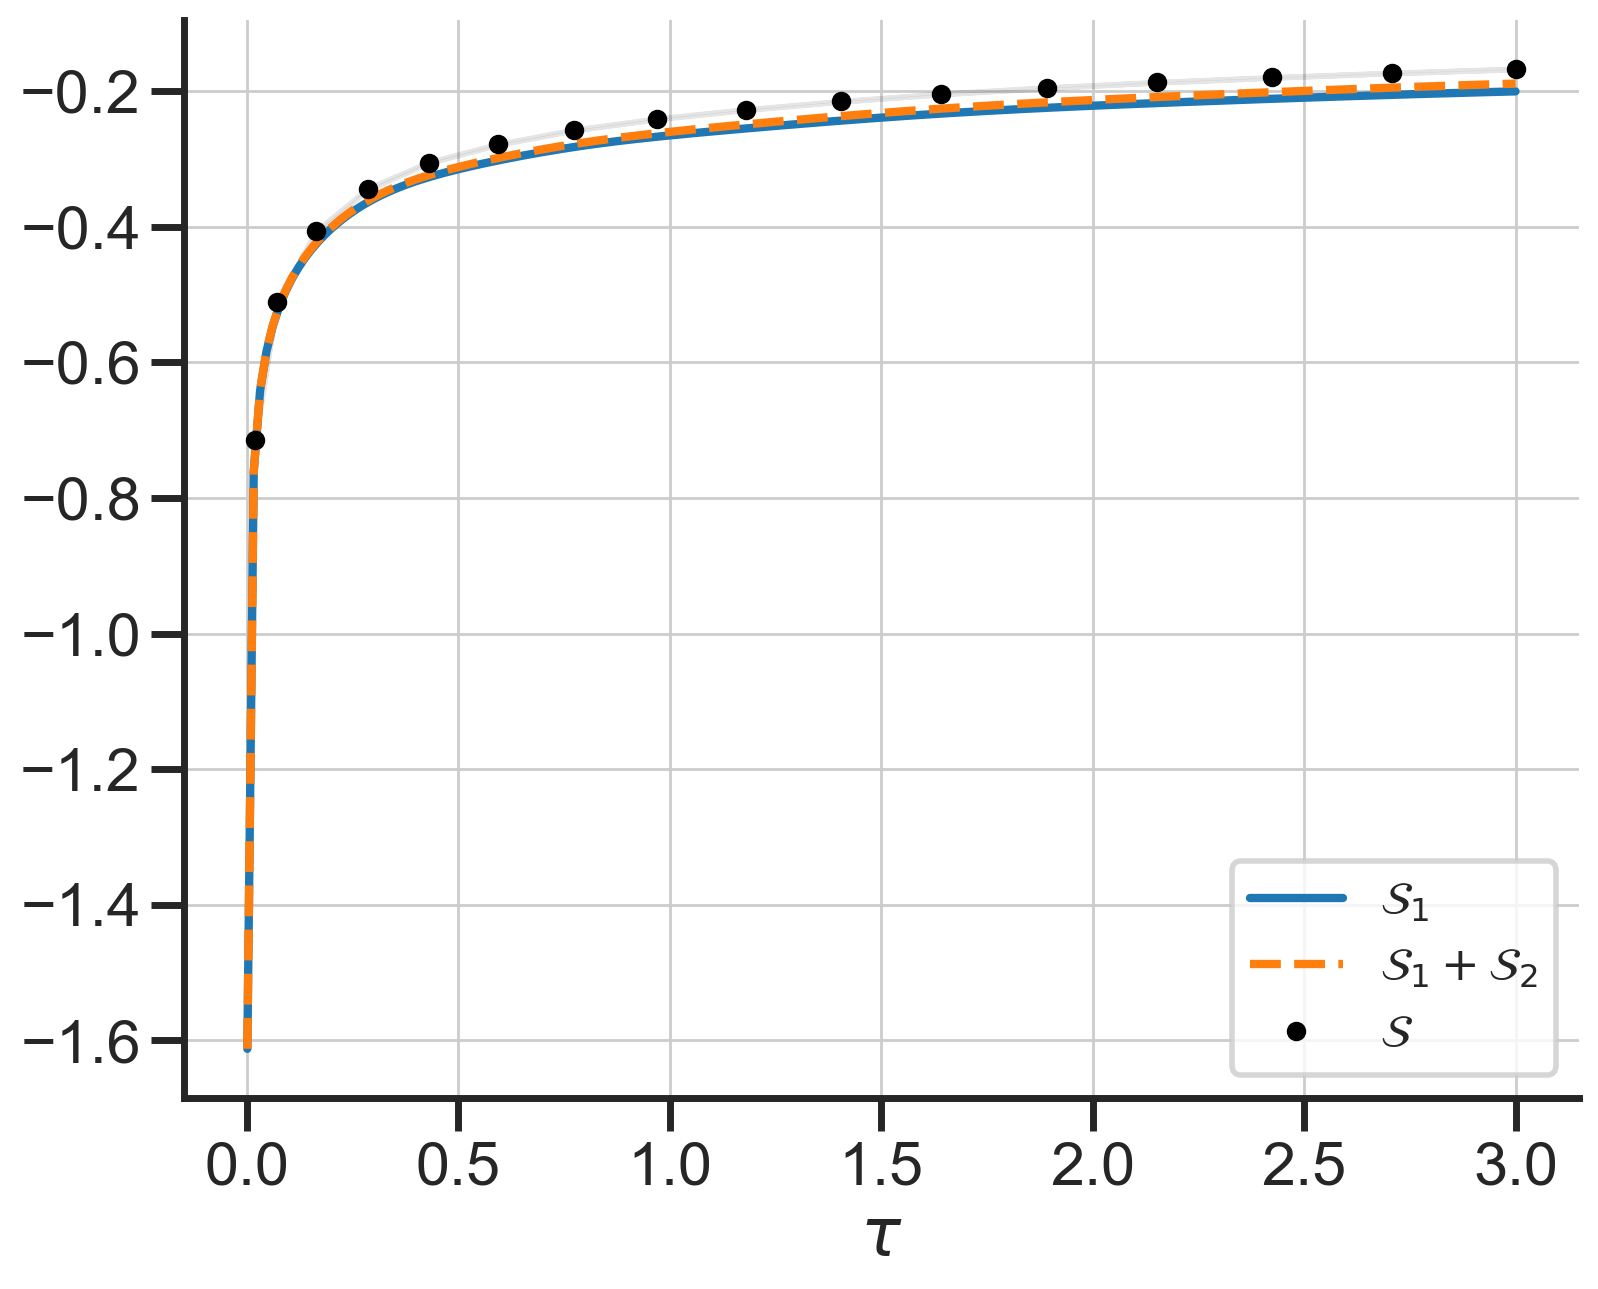

In [16]:
# plot ATM skew
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["atm_skew_1"], "-", label=r"$\mathcal{S}_1$")
ax.plot(
    Ts_bg,
    out_bg["atm_skew_1"] + out_bg["atm_skew_2"],
    "--",
    label=r"$\mathcal{S}_1+\mathcal{S}_2$",
)
ax.plot(Ts, out["atm_skew"], ".k", label=r"$\mathcal{S}$")
ax.fill_between(Ts, out["atm_skew_low"], out["atm_skew_high"], color="k", alpha=0.1)
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rbergomi/rbergomi_{date}_atm_skew.pdf", bbox_inches="tight")
plt.show()

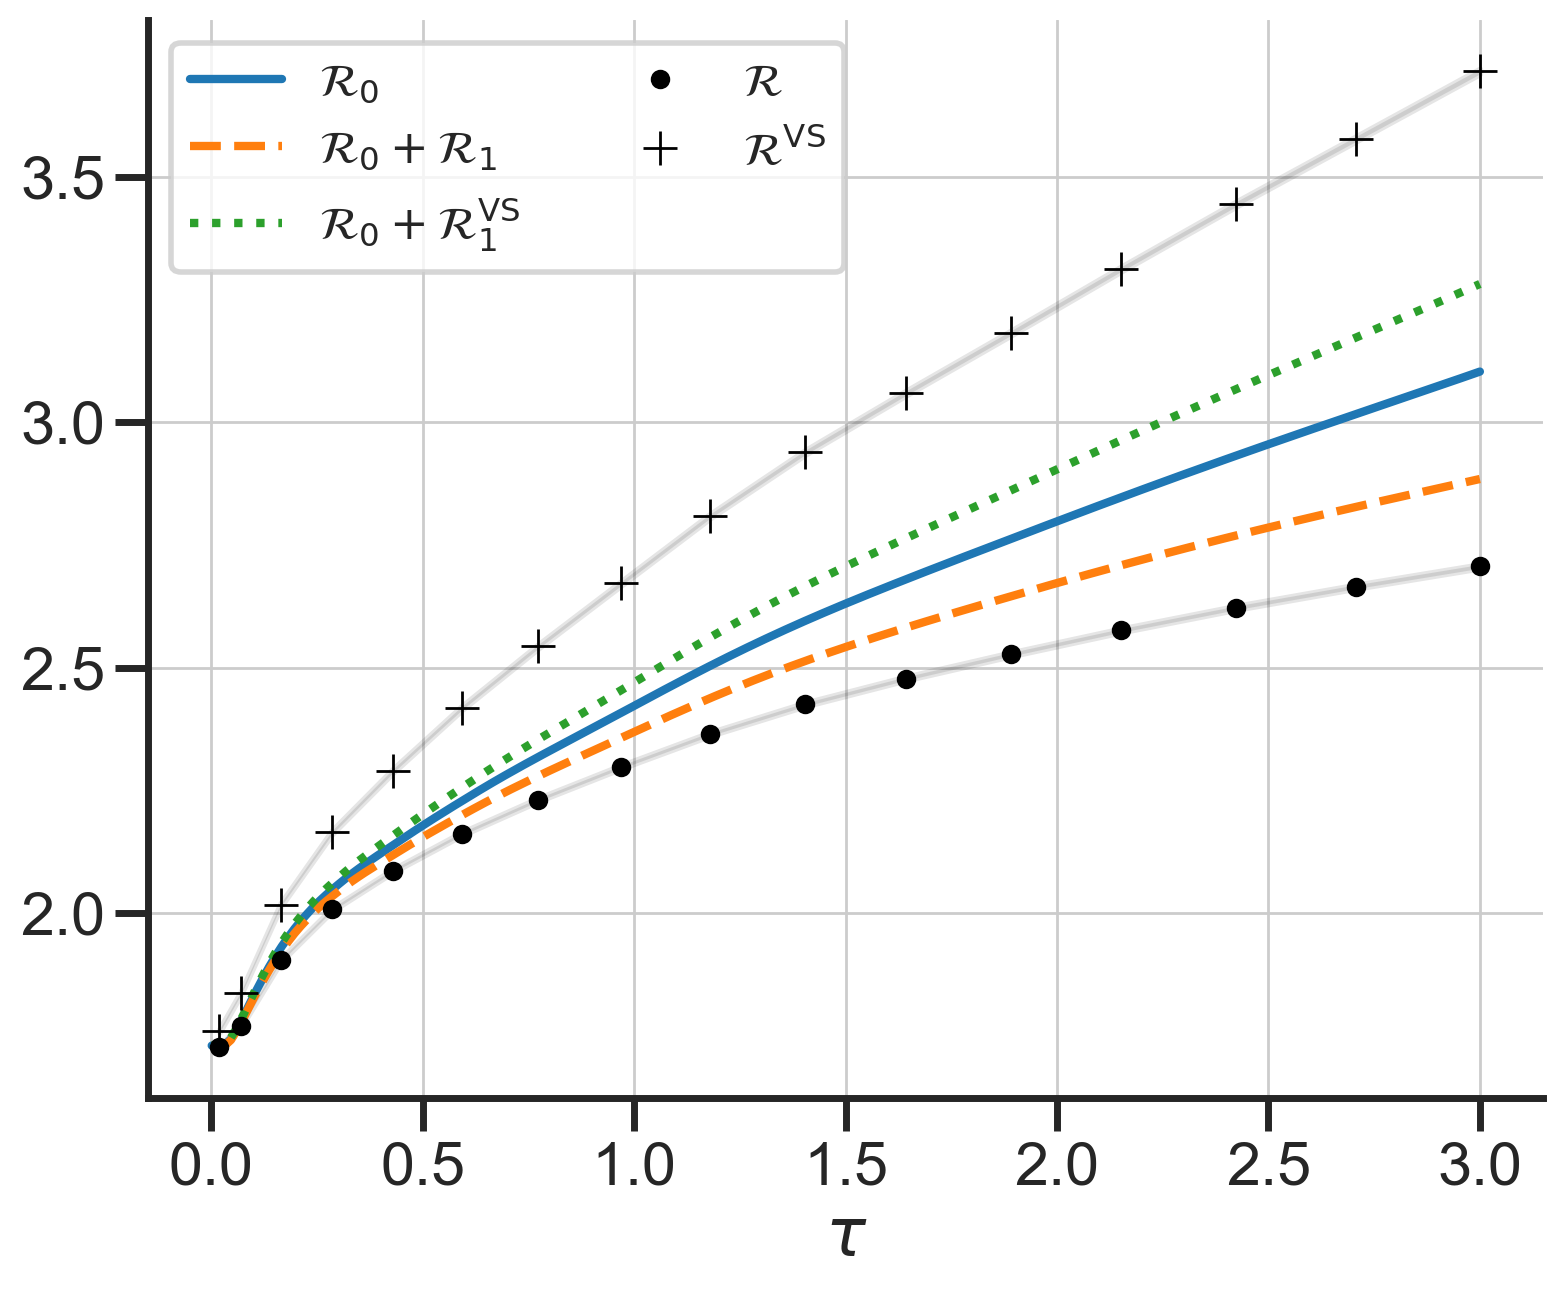

In [17]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_fd"], ".k", label=r"$\mathcal{R}$")
ax.fill_between(Ts, out["ssr_fd_low"], out["ssr_fd_high"], color="k", alpha=0.1)
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.fill_between(Ts, out["ssr_vs_low"], out["ssr_vs_high"], color="k", alpha=0.1)
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rbergomi/rbergomi_{date}_ssr.pdf", bbox_inches="tight")
plt.show()

# 2D error surface of the BG expansion

In [5]:
# parameters
date = DATES[0]
print(f"Using parameters from {date}")

model = "rough_bergomi"
kind_interp = "cubic"
xi0 = get_xi0_interpolator(date, model, kind=kind_interp)
params = get_params(date=date, model=model)

# model
rbergomi = RoughBergomiModel(params=params, xi0=xi0)
rbergomi

Using parameters from 2024-05-06


RoughBergomiModel with parameters:
H=0.23, eta=1.5, rho=-0.62, s0=1.0

## H-eta

In [10]:
# Monte Carlo parameters
n_mc = 2 * 10**5
n_disc = 200
n_quad = 40
eps_ssr = 1e-3

In [ ]:
# H-eta error surface

# fix maturities
Ts = [0.1, 0.5, 1.0]

# grid parameters
nx = 20
ny = 20
xs = np.linspace(0.05, 0.5, nx)
ys = np.linspace(0.1, 2, ny)
sgn_rel_err = np.zeros((len(Ts), len(xs), len(ys)))

for i, H_i in enumerate(xs):
    print("\nH=", H_i)
    print(f"{i + 1}/{len(xs)}", end="\r", flush=True)
    for j, eta_j in enumerate(ys):
        params_i_j = {"H": H_i, "eta": eta_j, "rho": params["rho"]}
        rbergomi = RoughBergomiModel(params=params_i_j, xi0=xi0)

        # SSR via fintie difference
        out = rbergomi.ssr_all(
            Ts,
            n_mc=n_mc,
            n_disc=n_disc,
            n_quad=n_quad,
            seed=SEED,
            eps_ssr=eps_ssr,
            conditioning=True,
            n_loop=4,
        )
        ssr_fd = out["ssr_fd"]

        # SSR expansion
        out_bg = rbergomi.ssr_bg_all(Ts, n_quad=n_quad)
        ssr_expansion = out_bg["ssr_0"] + out_bg["ssr_1"]

        # compute signed relative error
        sgn_rel_err[:, i, j] = (ssr_expansion - ssr_fd) / ssr_fd


H= 0.05


1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 0.5000
3/3: expiry 1.0000
1/3: expiry 0.1000
2/3: expiry 

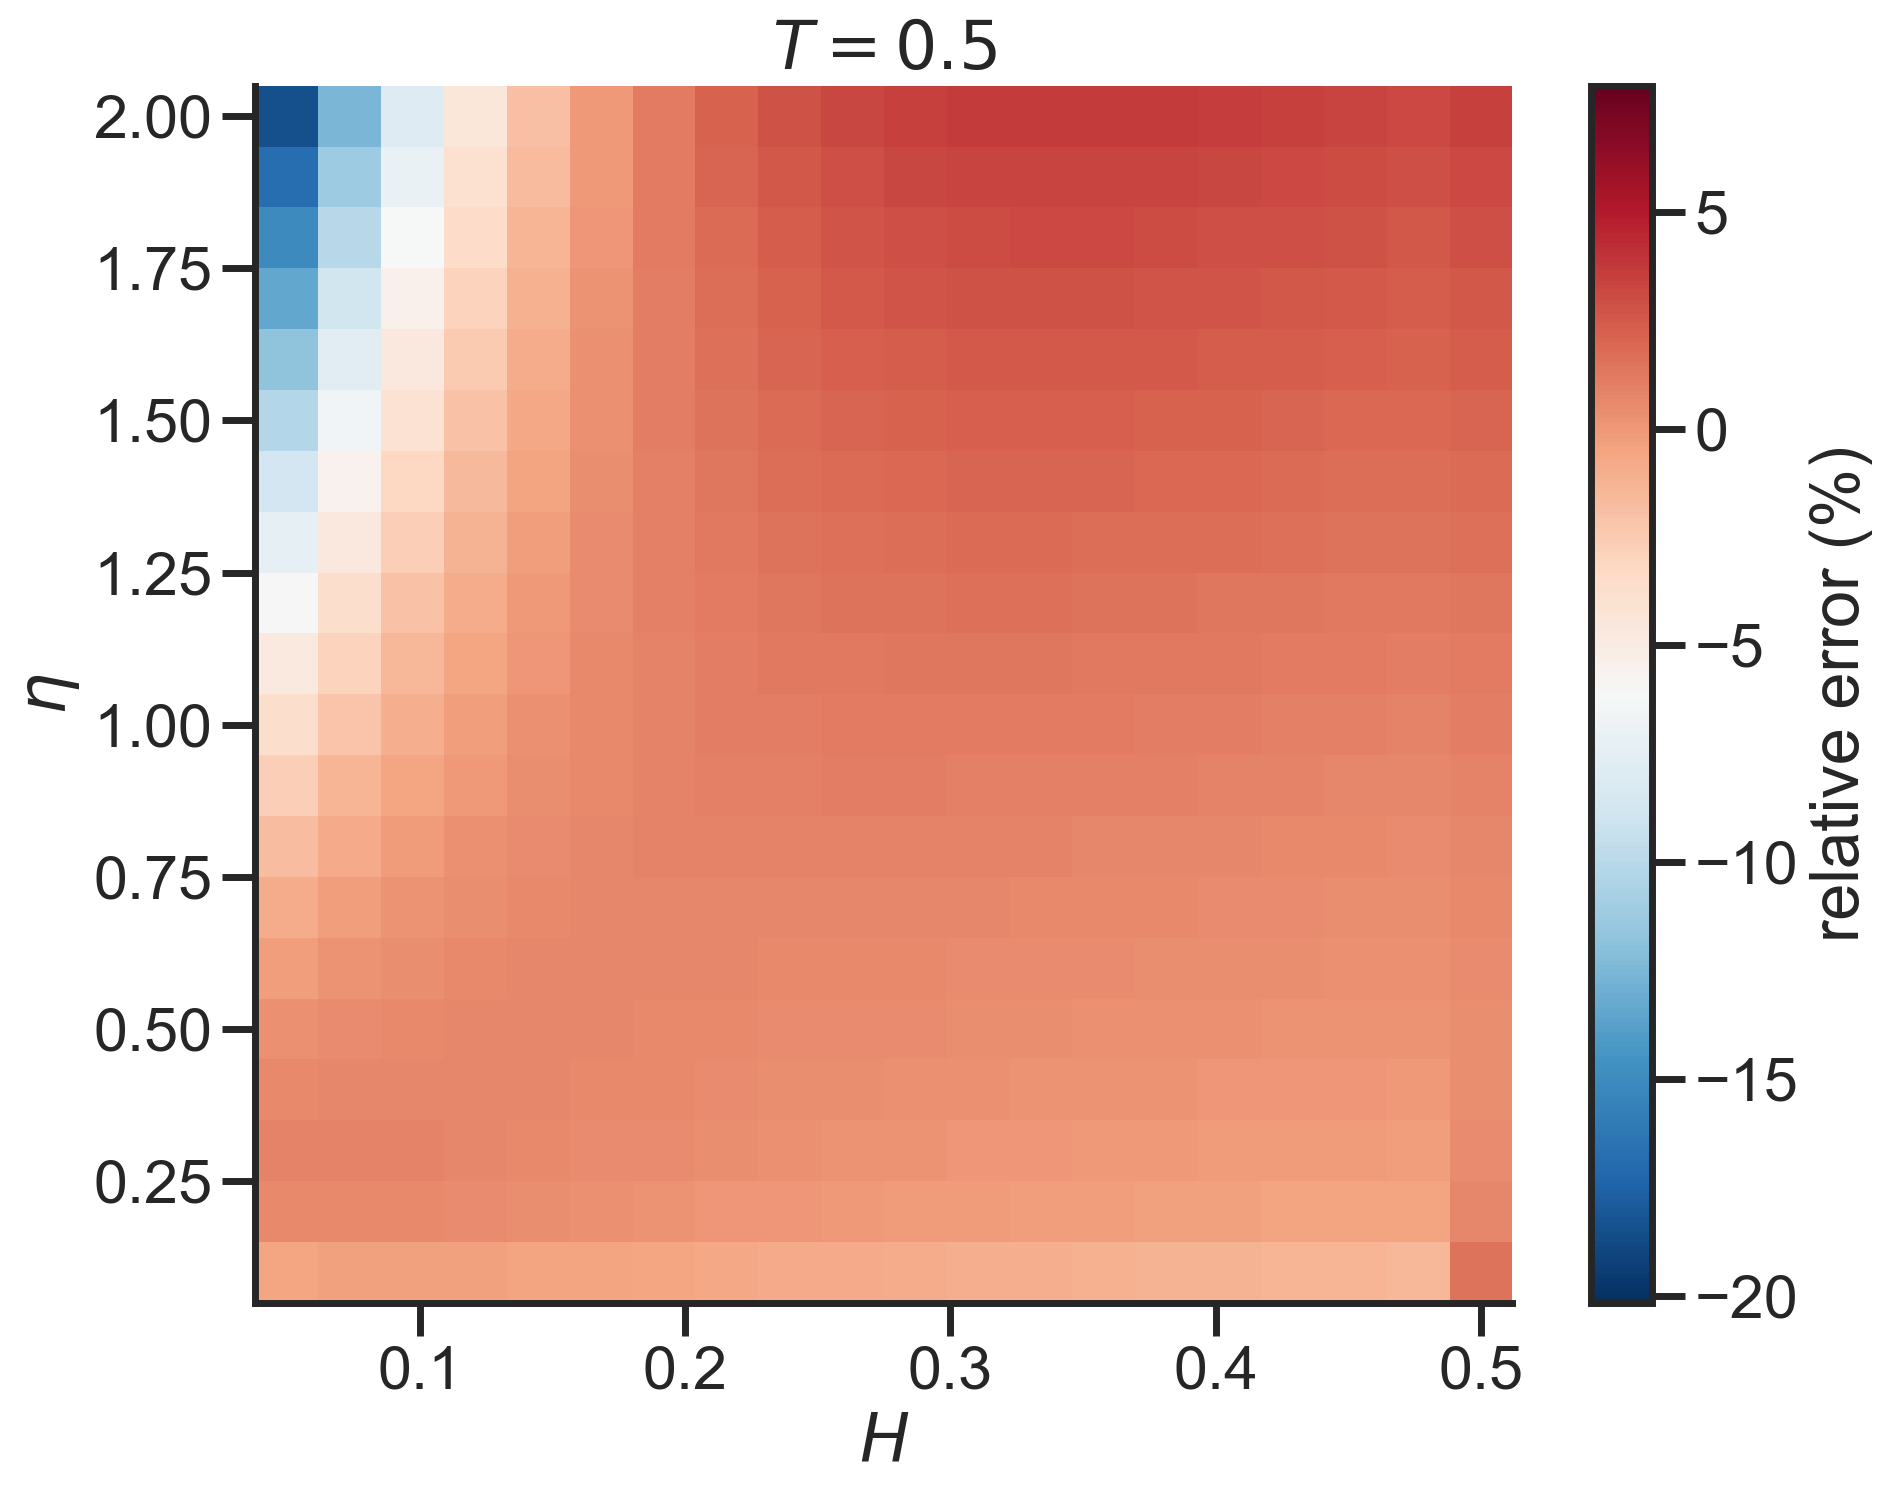

In [17]:
x_grid, y_grid = np.meshgrid(xs, ys, indexing="ij")

vmin = 100 * np.min(sgn_rel_err)
vmax = 100 * np.max(sgn_rel_err)
idx_T = 1  # pick maturity

fig, ax = plt.subplots(figsize=(10, 8))
pcm = ax.pcolormesh(
    x_grid,
    y_grid,
    100 * sgn_rel_err[idx_T, :, :],
    shading="auto",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
)
fig.colorbar(pcm, ax=ax, label="relative error (%)")
ax.set_xlabel(r"$H$")
ax.set_ylabel(r"$\eta$")
ax.set_title(f"$T={Ts[idx_T]}$")
plt.tight_layout()
if SAVEFIG:
    fig.savefig(
        f"figures/rbergomi/rbergomi_{date}_ssr_rel_error_T_{Ts[idx_T]}.pdf",
        bbox_inches="tight",
    )
plt.show()